In [30]:
import pandas as pd
import numpy as np

path = "archive\\players_data-2025_2026.csv"


In [31]:
df = pd.read_csv(path)

df.describe(include='all')

,Rk,Player,Nation,Pos,Squad,Comp,Age,Born,MP,Starts,...,CrdY_stats_misc,CrdR_stats_misc,2CrdY,Fls,Fld,Off,Crs,Int,TklW,OG
count,2839.000000,2839,2836,2839,2839,2839,2837.000000,2837.000000,2839.000000,2839.000000,...,2839.000000,2839.000000,2839.000000,2839.000000,2839.000000,2839.000000,2839.000000,2839.000000,2839.000000,2839.000000
unique,NaN,2687,115,9,96,5,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,Nicolás González,es ESP,MF,Marseille,es La Liga,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,3,419,922,38,611,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,1420.000000,NaN,NaN,NaN,NaN,NaN,24.855834,1999.802256,19.138781,13.576611,...,2.412821,0.121169,0.041564,14.497710,13.752730,2.060937,21.657978,10.141951,11.924974,0.045791
std,819.693032,NaN,NaN,NaN,NaN,NaN,4.623789,4.633160,11.520385,11.225366,...,2.526406,0.352339,0.204853,13.493894,14.665142,3.801657,34.963118,11.810994,12.430342,0.228399
min,1.000000,NaN,NaN,NaN,NaN,NaN,15.000000,1983.000000,1.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,710.500000,NaN,NaN,NaN,NaN,NaN,21.000000,1997.000000,9.000000,3.000000,...,0.000000,0.000000,0.000000,2.000000,2.000000,0.000000,1.000000,1.000000,1.000000,0.000000
50%,1420.000000,NaN,NaN,NaN,NaN,NaN,25.000000,2000.000000,20.000000,12.000000,...,2.000000,0.000000,0.000000,12.000000,9.000000,1.000000,6.000000,5.000000,8.000000,0.000000
75%,2129.500000,NaN,NaN,NaN,NaN,NaN,28.000000,2003.000000,29.000000,23.000000,...,4.000000,0.000000,0.000000,23.000000,20.000000,2.500000,26.500000,16.000000,19.000000,0.000000


In [32]:
jugador = df["Gls"].idxmax()
print(df.loc[jugador])

Rk                 1320
Player       Harry Kane
Nation          eng ENG
Pos               FW,MF
Squad     Bayern Munich
              ...      
Off                  20
Crs                  12
Int                   8
TklW                 13
OG                    0
Name: 1319, Length: 102, dtype: object


In [33]:
features = ["Gls", "Ast", "Min", "Int"]
for feature in features:
    df[feature] = pd.to_numeric(df[feature], errors='coerce').astype(float)

df_model = df.dropna(subset=features).copy()

In [34]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X = df_model[features].copy()

X_scaled = pd.DataFrame(
    scaler.fit_transform(X),
    columns=X.columns,
    index=X.index
)

X_scaled.head()

,Gls,Ast,Min,Int
0,0.797892,2.095652,1.277629,0.580752
1,-0.566285,-0.632501,-1.247683,-0.774157
2,-0.566285,-0.632501,-1.095043,-0.689475
3,0.115804,-0.632501,-0.558206,-0.604793
4,-0.566285,-0.632501,-1.122040,-0.689475


In [35]:
vector_jugador = X_scaled.loc[jugador]

print(vector_jugador)

Gls    11.711306
Ast     2.095652
Min     1.202867
Int    -0.181384
Name: 1319, dtype: float64


In [36]:
candidatos = X_scaled.drop(jugador)

candidatos.head()

,Gls,Ast,Min,Int
0,0.797892,2.095652,1.277629,0.580752
1,-0.566285,-0.632501,-1.247683,-0.774157
2,-0.566285,-0.632501,-1.095043,-0.689475
3,0.115804,-0.632501,-0.558206,-0.604793
4,-0.566285,-0.632501,-1.122040,-0.689475


¿qué operación de la Unidad II deben aplicarle obligatoriamente a estas 4 columnas para que los Minutos_Jugados (rango en miles) no aplasten matemáticamente a los Goles (rango en decenas)?

Antes de calcular las distancias es necesario estandarizar las variables, ya que están medidas en escalas muy diferentes. Para esto se le aplicó un escalamiento por z-score utilizando standarscaler de scikit-learn.

Distancia Manhattan:
$$
d_M(x,y)=\sum_{i=1}^{n}|x_i-y_i|
$$

In [37]:
#Usando distancia euclidiana 

distancias = candidatos.apply(
    lambda candidato: np.linalg.norm(candidato - vector_jugador),
    axis=1
)

cercano_eu = distancias.idxmin()

print(df.loc[cercano_eu])

Rk                   1105
Player     Erling Haaland
Nation             no NOR
Pos                    FW
Squad     Manchester City
               ...       
Off                     5
Crs                     3
Int                   4.0
TklW                    7
OG                      0
Name: 1104, Length: 102, dtype: object


In [38]:
#Usando distancia de Manhattan

def distancia_manhattan(vector1, vector2):
    return np.sum(np.abs(vector1 - vector2))


distancias = candidatos.apply(
    lambda candidato: distancia_manhattan(candidato, vector_jugador),
    axis=1
)

cercano_man = distancias.idxmin()
print(df.loc[cercano_man])

Rk                 1702
Player    Kylian Mbappé
Nation           fr FRA
Pos                  FW
Squad       Real Madrid
              ...      
Off                  39
Crs                  26
Int                 3.0
TklW                  1
OG                    0
Name: 1701, Length: 102, dtype: object


Análisis

En este caso, tanto para cada técnica dieron jugadores diferentes. Esto ocurre porque ambas métricas calculan la distancia entre los jugadores de forma distinta. La Distancia Euclidiana (L2) eleva al cuadrado las diferencias de cada característica antes de sumarlas, por lo que una diferencia grande en alguna variable tiene un mayor impacto en la distancia total. Por otro lado, la Distancia Manhattan (L1) suma directamente las diferencias absolutas entre cada característica. Debido a esto, una diferencia grande en una sola variable no afecta de la misma manera que en la distancia Euclidiana.


 Visualización multidimensional: Coordenadas Paralelas

Para representar los vectores de cuatro dimensiones se utilizará la técnica de Coordenadas Paralelas.

Esta técnica permite visualizar datos multidimensionales en una gráfica 2D, donde cada característica se representa mediante un eje paralelo. Cada jugador se representa como una línea que atraviesa los diferentes ejes de acuerdo con los valores de sus características.

En este caso se utilizarán las variables Goles (Gls), Asistencias (Ast), Minutos jugados (Min) e Intercepciones (Int). Para mantener la misma escala utilizada en el cálculo de las distancias, se utilizarán los valores previamente estandarizados mediante z-score.

Si dos jugadores tienen perfiles similares, sus líneas deberán encontrarse cercanas o seguir trayectorias similares a través de los cuatro ejes.

In [39]:
posibles_random = X_scaled.drop(
    index=[
        jugador,
        cercano_eu,
        cercano_man
    ]
)

indice_aleatorio = posibles_random.sample(
    n=1,
    random_state=42
).index[0]


print(
    "Jugador aleatorio:",
    df.loc[indice_aleatorio, "Player"]
)


Jugador aleatorio: Sam Byram


In [40]:
datos_grafica = X_scaled.loc[
    [
        jugador,
        cercano_eu,
        cercano_man,
        indice_aleatorio
    ]
].copy()

datos_grafica["Jugador"] = [
    "Harry Kane",
    "Haaland(Euclidiano)",
    "Mbappé(Manhattan)",
    "Byram (Aleatorio)"
]

datos_grafica


,Gls,Ast,Min,Int,Jugador
1319,11.711306,2.095652,1.202867,-0.181384,Harry Kane
1104,8.641908,3.732544,1.800967,-0.520111,Haaland(Euclidiano)
1701,7.959820,2.095652,1.433384,-0.604793,Mbappé(Manhattan)
415,-0.566285,-0.632501,-1.255990,-0.858839,Byram (Aleatorio)


Note: you may need to restart the kernel to use updated packages.


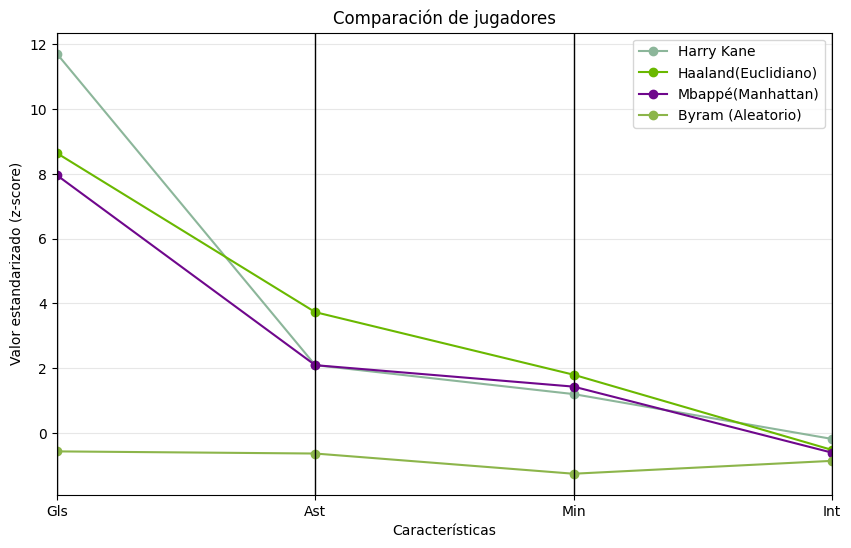

In [42]:
#Le voy a agregar este install para ver si se ve bien en github
%pip install matplotlib
import matplotlib.pyplot as plt
from pandas.plotting import parallel_coordinates

plt.figure(figsize=(10, 6))

parallel_coordinates(
    datos_grafica,
    class_column="Jugador",
    marker="o"
)

plt.title("Comparación de jugadores")
plt.xlabel("Características")
plt.ylabel("Valor estandarizado (z-score)")
plt.grid(alpha=0.3)

plt.show()